# Notebook 09 — Time-Based Demand Analysis

**Tier:** 1 / 2 — Descriptive & Diagnostic  
**Purpose:** Understand hourly, daily, and monthly demand patterns.  
**Input:** `outputs/feature_store.parquet`  
**Output:** Charts in `outputs/plots/09_*`, tables in `outputs/reports/`

In [1]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 9.1 Hourly Demand

In [2]:
hourly = df.groupby('hour').agg(
    bookings=('Booking ID','count'),
    completed=('is_completed','sum'),
    cancelled=('is_cancelled','sum'),
    avg_vtat=('Avg VTAT','mean'),
    avg_fare=('Booking Value','mean'),
).round(2)
hourly['completion_rate_pct'] = (hourly['completed']/hourly['bookings']*100).round(1)
hourly['cancellation_rate_pct'] = (hourly['cancelled']/hourly['bookings']*100).round(1)
print('Hourly stats (first 12 hours):')
print(hourly.head(12).to_string())

Hourly stats (first 12 hours):
      bookings  completed  cancelled  avg_vtat  avg_fare  completion_rate_pct  cancellation_rate_pct
hour                                                                                                
0         1373        858        340      8.41    507.77                 62.5                   24.8
1         1360        828        344      8.39    515.64                 60.9                   25.3
2         1339        853        297      8.55    508.92                 63.7                   22.2
3         1383        860        355      8.36    505.72                 62.2                   25.7
4         1321        830        338      8.54    508.94                 62.8                   25.6
5         2786       1715        736      8.45    499.58                 61.6                   26.4
6         4160       2609       1005      8.47    516.70                 62.7                   24.2
7         5450       3346       1382      8.45    503.10    

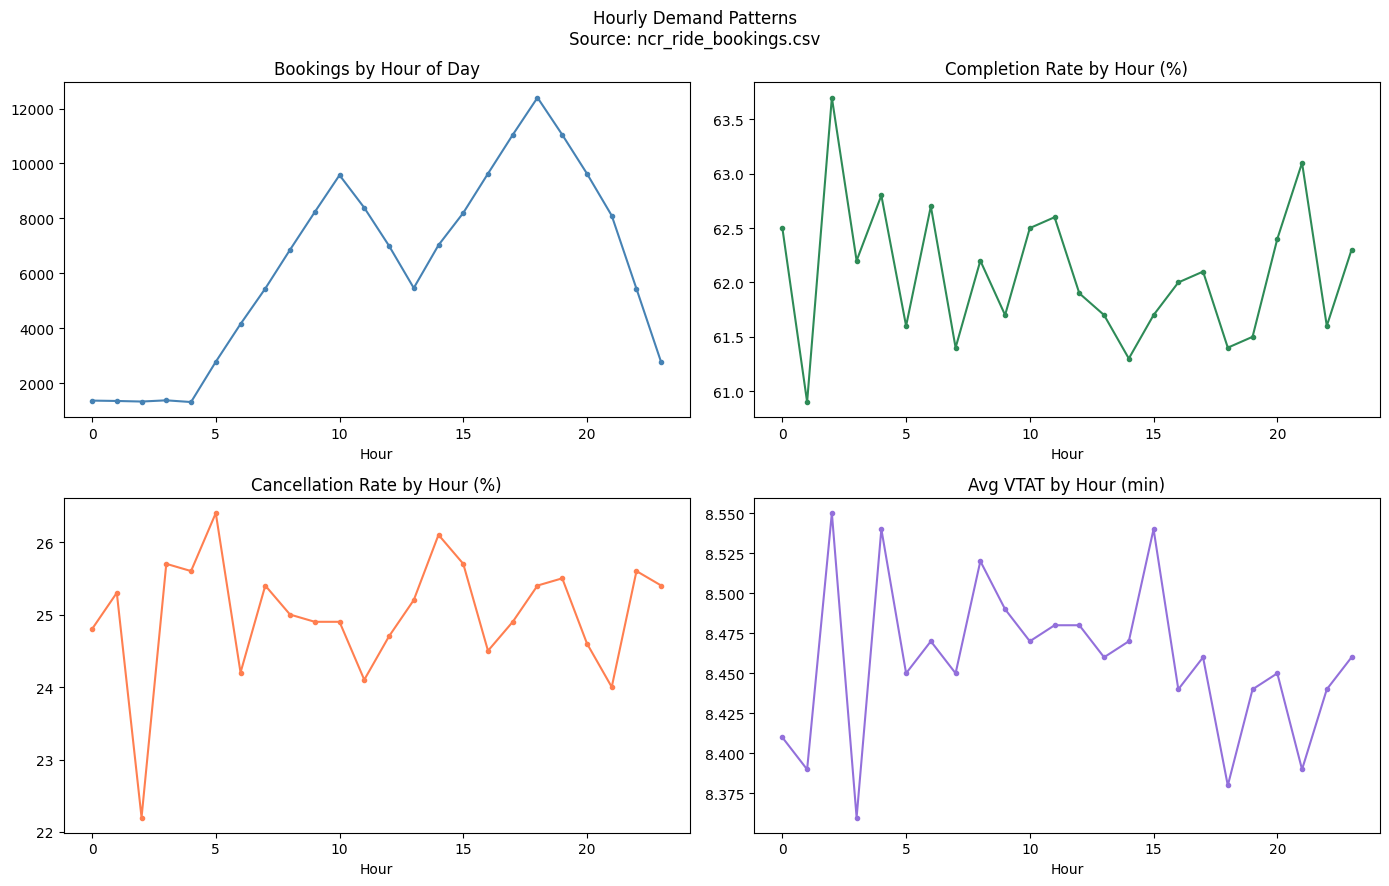

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
hourly['bookings'].plot(ax=axes[0,0], color='steelblue', marker='.')
axes[0,0].set_title('Bookings by Hour of Day'); axes[0,0].set_xlabel('Hour')

hourly['completion_rate_pct'].plot(ax=axes[0,1], color='seagreen', marker='.')
axes[0,1].set_title('Completion Rate by Hour (%)'); axes[0,1].set_xlabel('Hour')

hourly['cancellation_rate_pct'].plot(ax=axes[1,0], color='coral', marker='.')
axes[1,0].set_title('Cancellation Rate by Hour (%)'); axes[1,0].set_xlabel('Hour')

hourly['avg_vtat'].plot(ax=axes[1,1], color='mediumpurple', marker='.')
axes[1,1].set_title('Avg VTAT by Hour (min)'); axes[1,1].set_xlabel('Hour')

fig.suptitle('Hourly Demand Patterns\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/09_hourly_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.2 Day-of-Week Demand

Day-of-Week stats:
           bookings  completed        gbv  completion_rate_pct  avg_fare
day_name                                                                
Monday        21644      13318  6414387.0                 61.5     482.0
Tuesday       21391      13171  6416890.0                 61.6     487.0
Wednesday     21413      13296  6578787.0                 62.1     495.0
Thursday      21215      13206  6557680.0                 62.2     497.0
Friday        21397      13253  6674597.0                 61.9     504.0
Saturday      21542      13442  9571155.0                 62.4     712.0
Sunday        21398      13314  9632687.0                 62.2     724.0


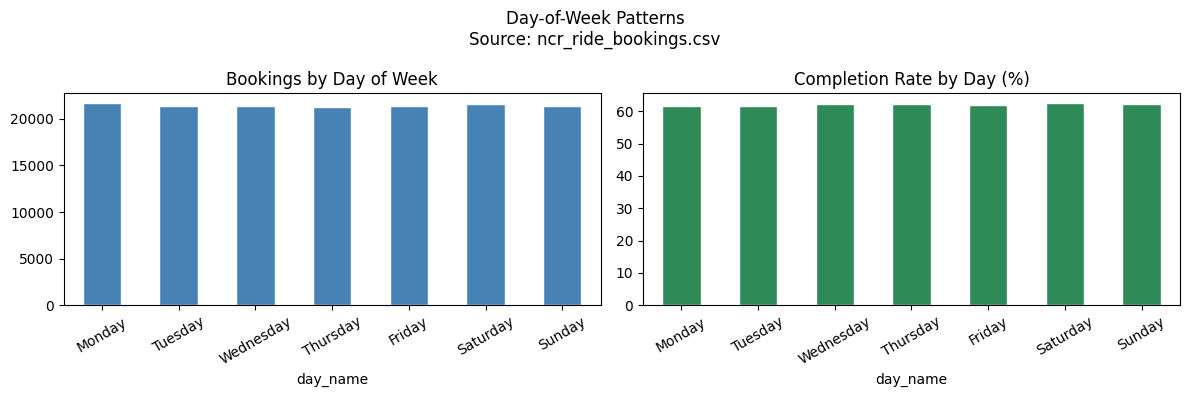

In [4]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_name').agg(
    bookings=('Booking ID','count'),
    completed=('is_completed','sum'),
    gbv=('Booking Value','sum'),
).reindex(dow_order).round(2)
dow['completion_rate_pct'] = (dow['completed']/dow['bookings']*100).round(1)
dow['avg_fare'] = (dow['gbv'] / dow['completed']).round(0)
print('Day-of-Week stats:'); print(dow.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dow['bookings'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Bookings by Day of Week'); axes[0].tick_params(axis='x', rotation=30)
dow['completion_rate_pct'].plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Completion Rate by Day (%)'); axes[1].tick_params(axis='x', rotation=30)
fig.suptitle('Day-of-Week Patterns\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/09_dow_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.3 Monthly Seasonality

Monthly stats:
     bookings  completed        gbv  avg_fare  completion_rate_pct
Jan     12861       7951  4411069.0    503.60                 61.8
Feb     11927       7368  4085790.0    507.61                 61.8
Mar     12719       7954  4568188.0    526.23                 62.5
Apr     12199       7632  4253789.0    509.01                 62.6
May     12778       7905  4320679.0    498.18                 61.9
Jun     12440       7757  4325660.0    509.20                 62.4
Jul     12897       7926  4365923.0    500.16                 61.5
Aug     12636       7780  4243509.0    498.36                 61.6
Sep     12248       7542  4191393.0    505.90                 61.6
Oct     12651       7905  4417170.0    509.71                 62.5
Nov     12394       7659  4343395.0    514.07                 61.8
Dec     12250       7621  4319618.0    517.82                 62.2


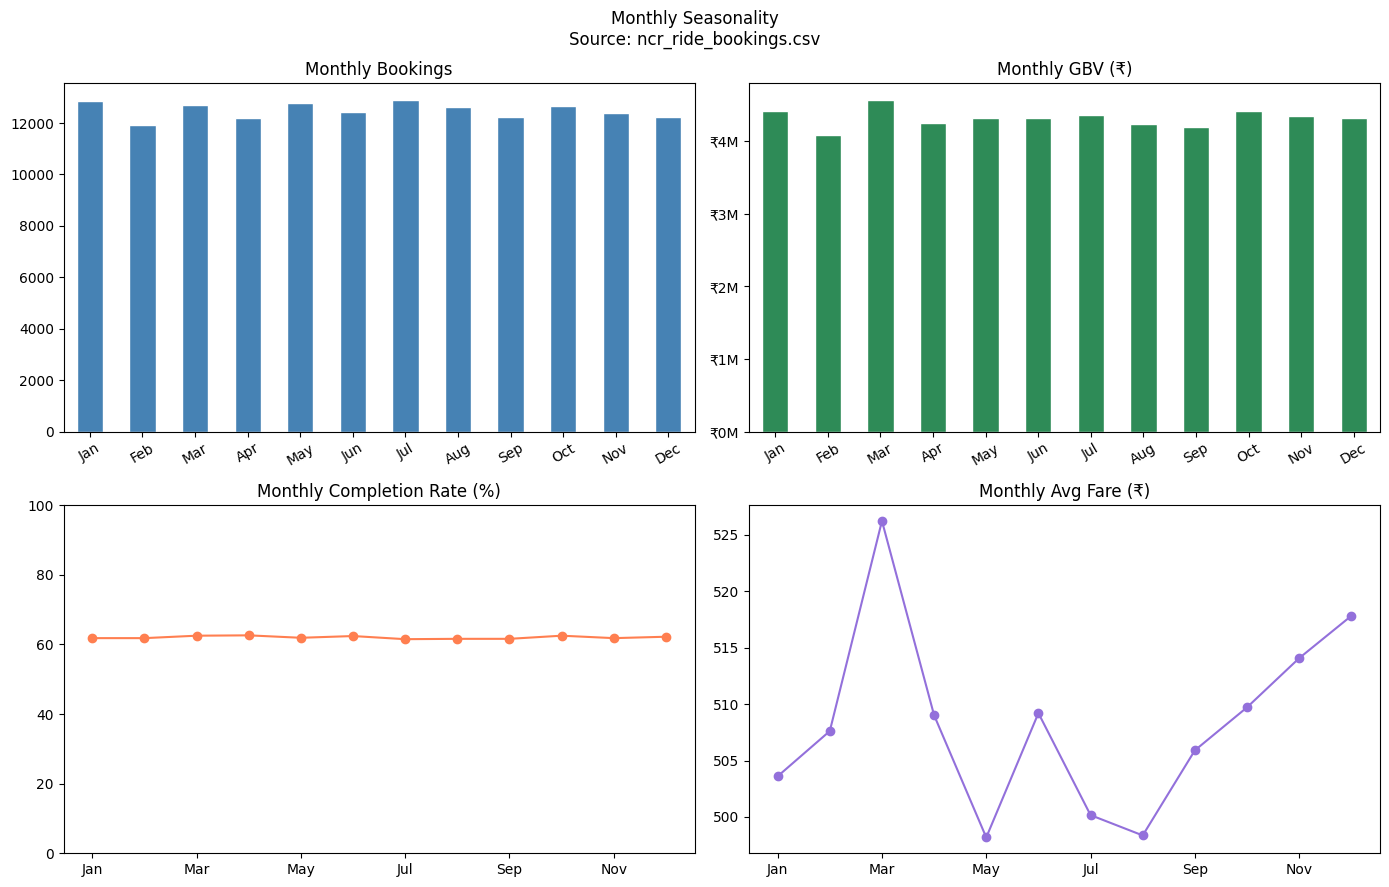

In [5]:
monthly = df.groupby('month').agg(
    bookings=('Booking ID','count'),
    completed=('is_completed','sum'),
    gbv=('Booking Value','sum'),
    avg_fare=('Booking Value','mean'),
).round(2)
monthly['completion_rate_pct'] = (monthly['completed']/monthly['bookings']*100).round(1)
monthly.index = month_labels
print('Monthly stats:'); print(monthly.to_string())
monthly.to_csv('outputs/reports/monthly_stats.csv')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
monthly['bookings'].plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Monthly Bookings'); axes[0,0].tick_params(axis='x', rotation=30)
monthly['gbv'].plot(kind='bar', ax=axes[0,1], color='seagreen', edgecolor='white')
axes[0,1].set_title('Monthly GBV (₹)'); axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e6:.0f}M'))
monthly['completion_rate_pct'].plot(ax=axes[1,0], marker='o', color='coral')
axes[1,0].set_title('Monthly Completion Rate (%)'); axes[1,0].set_ylim(0,100)
monthly['avg_fare'].plot(ax=axes[1,1], marker='o', color='mediumpurple')
axes[1,1].set_title('Monthly Avg Fare (₹)')
fig.suptitle('Monthly Seasonality\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/09_monthly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.4 Time-Slot Analysis

Time Slot stats:
               bookings  completed  avg_vtat  avg_fare  avg_driver_rating  completion_rate_pct
time_slot                                                                                     
Early Morning      9562       5944      8.45    506.55               4.23                 62.2
Morning           34282      21289      8.48    512.12               4.23                 62.1
Afternoon         27897      17278      8.47    505.08               4.23                 61.9
Evening           52323      32302      8.45    506.68               4.23                 61.7
Night             23174      14465      8.43    509.72               4.24                 62.4
Late Night         2762       1722      8.46    517.68               4.22                 62.3


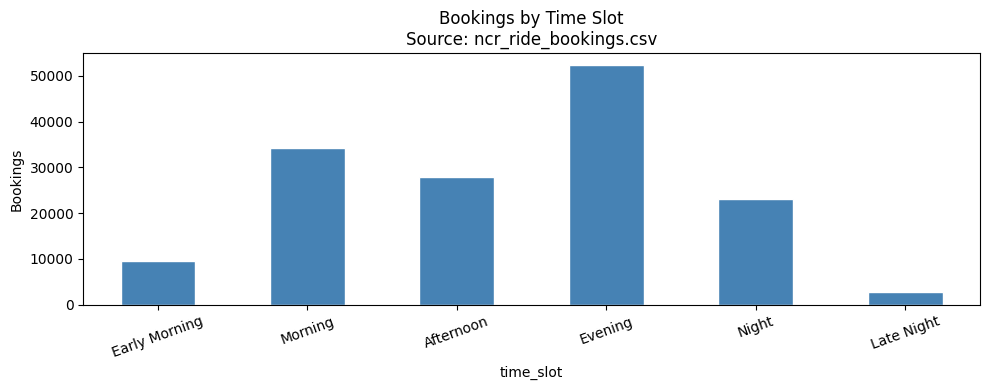

In [6]:
slot_stats = df.groupby('time_slot', observed=True).agg(
    bookings=('Booking ID','count'),
    completed=('is_completed','sum'),
    avg_vtat=('Avg VTAT','mean'),
    avg_fare=('Booking Value','mean'),
    avg_driver_rating=('Driver Ratings','mean'),
).reindex([s for s in slot_order if s in df['time_slot'].cat.categories]).round(2)
slot_stats['completion_rate_pct'] = (slot_stats['completed']/slot_stats['bookings']*100).round(1)
print('Time Slot stats:'); print(slot_stats.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
slot_stats['bookings'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Bookings by Time Slot\nSource: ncr_ride_bookings.csv')
ax.set_ylabel('Bookings'); ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
fig.savefig('outputs/plots/09_slot_bookings.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.5 Weekend vs Weekday

In [7]:
we = df.groupby('is_weekend').agg(
    bookings=('Booking ID','count'),
    completed=('is_completed','sum'),
    gbv=('Booking Value','sum'),
    avg_fare=('Booking Value','mean'),
).round(2)
we.index = ['Weekday','Weekend']
we['completion_rate_pct'] = (we['completed']/we['bookings']*100).round(1)
print('Weekend vs Weekday:'); print(we.to_string())

Weekend vs Weekday:
         bookings  completed         gbv  avg_fare  completion_rate_pct
Weekday    107060      66244  32642341.0    448.99                 61.9
Weekend     42940      26756  19203842.0    655.47                 62.3


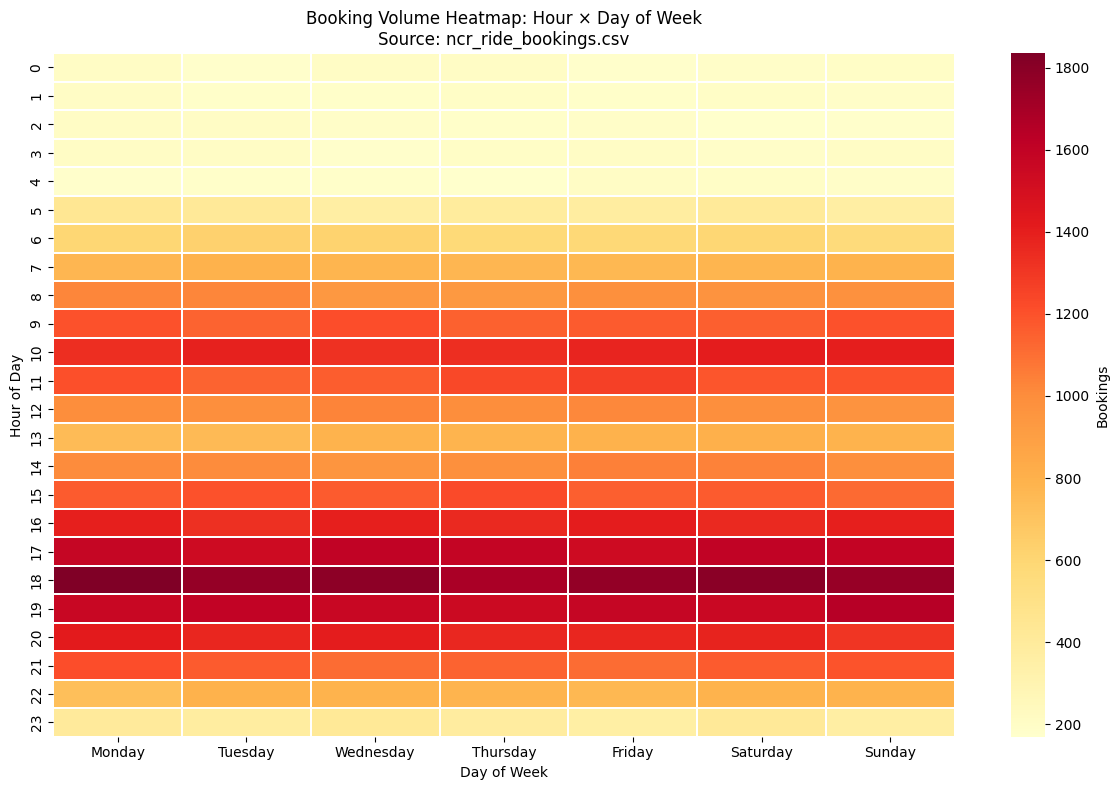

In [8]:
# Demand heatmap: hour x day_of_week
heat = df.pivot_table(index='hour', columns='day_name', values='Booking ID',
                      aggfunc='count', fill_value=0)[dow_order]
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(heat, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Bookings'})
ax.set_title('Booking Volume Heatmap: Hour × Day of Week\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('Day of Week'); ax.set_ylabel('Hour of Day')
plt.tight_layout()
fig.savefig('outputs/plots/09_heatmap_hour_dow.png', dpi=150, bbox_inches='tight')
plt.show()

## Limitations
- No external event or weather data to explain specific demand spikes.